# Model Inversion Red Teaming Linear

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
os.chdir("../..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)

In [2]:
import os 
os.getcwd()

'/home/lambpc/AMARANTH/opensourcegridmodeling'

## Data Preprocessing for RT Data

In [3]:
full_df = pd.read_csv('ElectricityDemandAustinTX/LoadForecastingAttacks/full_data.csv', parse_dates=['time'], index_col=['time'])

In [4]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/lambpc/AMARANTH/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [5]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
ar_test = test['load'].shift().bfill().values[:,None]
y_test = test['load'].values
X_test = np.hstack([ar_test, exog_te])

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

## Linear Regression

In [6]:
import onnx
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")

In [7]:
import hashlib

res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
print(res.digest())

b'x<[u\x81F\x17\\\xb5\xe7\x8d\x1b\xe0BO/'


In [8]:
def forecast(session, exog, y_init, label_name, input_name):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    y_ci = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
    yhat.append(yhat_i)
    return np.array(yhat)

def weekly_forecast(indexes, session, exog, y_init, label_name, input_name):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        y_hat_i = forecast(session, exog_i, yi, label_name, input_name)
        yhat.append(y_hat_i)
    mapie_hat = pd.DataFrame(np.vstack(yhat).reshape(-1))
    return mapie_hat.values.ravel()

In [9]:
# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
#pred_onx = sess.run([label_name], {input_name: exog_te})[0]

In [10]:
res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
print(res.digest())

b'x<[u\x81F\x17\\\xb5\xe7\x8d\x1b\xe0BO/'


In [11]:
preds_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

In [12]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(y_test, preds_onx))

MAE: 0.06649123114844394


# Convert to Original Shape

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
monthly_norm = full_df['load'].resample('MS').mean().bfill()
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('H').ffill().values

/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/tmp/pbs.4979530.sawtoothpbs/ipykernel_69858/673366613.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_base = pred_base.resample('H').ffill().values


In [14]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

lr_norm_df = pd.DataFrame({'h_norm':preds_onx, 'month':test.index.month, 'year':test.index.year})
pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
pred_lr = pred_lr_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_lr.resample('MS').mean().bfill()

In [15]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift_norm, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift_norm

Timestamp('2020-09-01 00:00:00')

In [16]:
over_load_loc = sampled_pred.index.get_loc(med_drift_norm)
over_load_loc

44

In [17]:
over_load = sampled_pred.loc[med_drift_norm]
over_load

np.float64(0.3752374385246229)

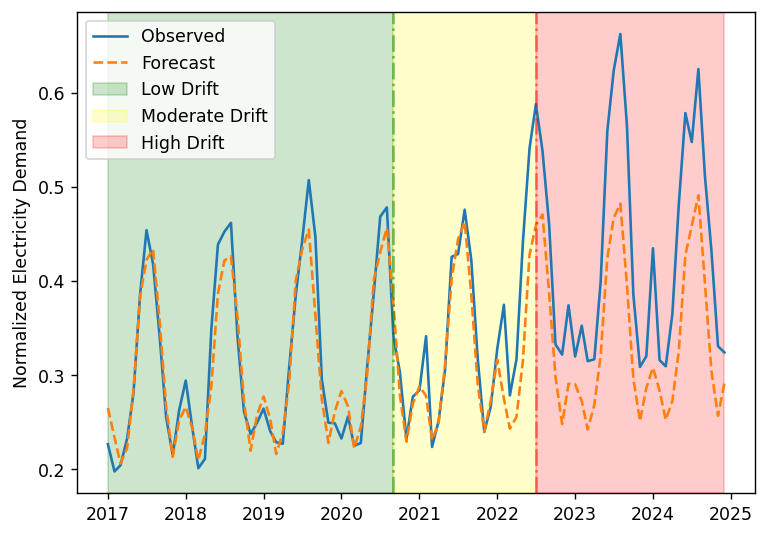

In [18]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift_norm, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift_norm, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift_norm,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [19]:
print('MAE:', ForecastingHelpers.compute_mae(monthly_norm['2017':], sampled_pred))

MAE: 0.046058989642268656


In [20]:
sampled_pred.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_results.csv")

## Teacher Student

Teacher is the model trained on the training data whereas the student is only trained on the real-time data (testing)

In [21]:
import copy 
teacher = copy.deepcopy(pred_lr)

In [22]:
X_test.shape

(70128, 13)

In [23]:
teacher.shape

(70128,)

The X_test is nxm and the teacher is px1 which means we 
a. have to down sample X_test to teacher (hoping we figure out the correct spacing)
or b. use an autoencoder to reduce the shape.

In [24]:
teacher

time
2017-01-01 00:00:00    0.161469
2017-01-01 01:00:00    0.144912
2017-01-01 02:00:00    0.131878
2017-01-01 03:00:00    0.123860
2017-01-01 04:00:00    0.121522
                         ...   
2024-12-31 19:00:00    0.354259
2024-12-31 20:00:00    0.336610
2024-12-31 21:00:00    0.315733
2024-12-31 22:00:00    0.293062
2024-12-31 23:00:00    0.270149
Length: 70128, dtype: float64

In [25]:
X_test

array([[-0.09924674,  0.48484848,  0.93      , ...,  0.        ,
         0.        ,  1.        ],
       [-0.09924674,  0.48484848,  0.93      , ...,  0.        ,
         0.25881905,  0.96592583],
       [-0.09546565,  0.48484848,  0.93      , ...,  0.        ,
         0.5       ,  0.8660254 ],
       ...,
       [-0.00225057,  0.57373737,  0.894     , ...,  1.        ,
        -0.70710678,  0.70710678],
       [-0.01743513,  0.57373737,  0.894     , ...,  1.        ,
        -0.5       ,  0.8660254 ],
       [-0.03103252,  0.57373737,  0.894     , ...,  1.        ,
        -0.25881905,  0.96592583]], shape=(70128, 13))

## The shapes are different so we might have to use option b

In [26]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-09-29 13:55:32.791822: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-29 13:55:32.846901: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-29 13:55:37.069204: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available:  3


In [40]:
# Use simple ANN
# Referencing https://arxiv.org/pdf/1503.02531
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization
model = Sequential([
    Normalization(input_shape=(X_test.shape[1],)),
    Dense(8, activation='relu'),
    Dropout(0.2),
    #Dense(8, activation='relu'),
    Dense(1)
])

/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

In [42]:
from keras.callbacks import EarlyStopping
model.fit(X_test, teacher, validation_split=0.2, epochs=1000, callbacks=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True))

Epoch 1/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0352 - mean_absolute_error: 0.1172 - val_loss: 0.0053 - val_mean_absolute_error: 0.0598
Epoch 2/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0053 - mean_absolute_error: 0.0587 - val_loss: 0.0048 - val_mean_absolute_error: 0.0562
Epoch 3/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0046 - mean_absolute_error: 0.0542 - val_loss: 0.0041 - val_mean_absolute_error: 0.0513
Epoch 4/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0041 - mean_absolute_error: 0.0508 - val_loss: 0.0035 - val_mean_absolute_error: 0.0475
Epoch 5/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0038 - mean_absolute_error: 0.0488 - val_loss: 0.0032 - val_mean_absolute_error: 0.0448
Epoch 6/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0035 - mean_absolute_error: 0.0470 - val_loss: 0.0030 - val_mean_absolute_error: 0.0430
Epoch 7/1000
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0034 - mea

In [43]:
y_pred = model.predict(X_test)

2192/2192 ━━━━━━━━━━━━━━━━━━━━ 2s 634us/step


In [44]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error')
  plt.legend()

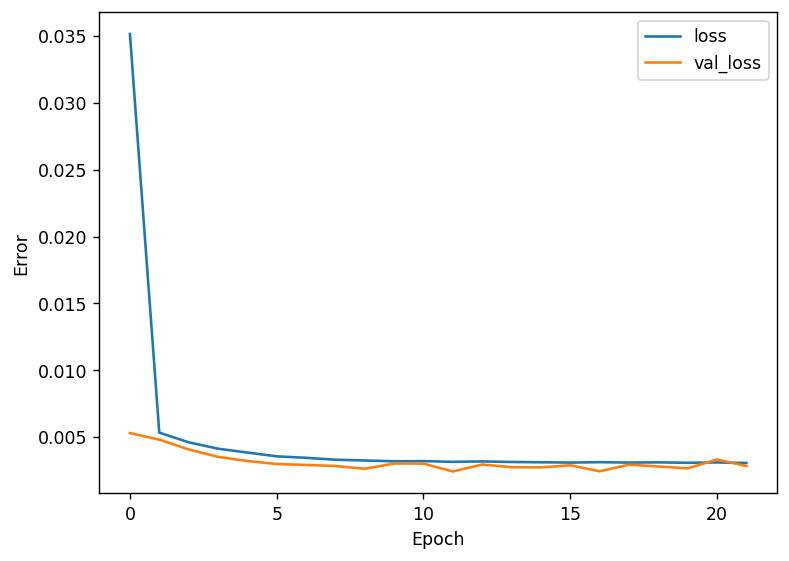

In [45]:
plot_loss(model.history)

In [46]:
from sklearn.metrics import mean_absolute_error
mae_error = mean_absolute_error(teacher, y_pred)

In [47]:
mae_error

0.03830907079033193

In [48]:
ann_ds = pd.Series(y_pred[:,0], index=test.index)

In [49]:
pred_lr

time
2017-01-01 00:00:00    0.161469
2017-01-01 01:00:00    0.144912
2017-01-01 02:00:00    0.131878
2017-01-01 03:00:00    0.123860
2017-01-01 04:00:00    0.121522
                         ...   
2024-12-31 19:00:00    0.354259
2024-12-31 20:00:00    0.336610
2024-12-31 21:00:00    0.315733
2024-12-31 22:00:00    0.293062
2024-12-31 23:00:00    0.270149
Length: 70128, dtype: float64

In [50]:
ann_ds

time
2017-01-01 00:00:00    0.223009
2017-01-01 01:00:00    0.207471
2017-01-01 02:00:00    0.193536
2017-01-01 03:00:00    0.186618
2017-01-01 04:00:00    0.184064
                         ...   
2024-12-31 19:00:00    0.335658
2024-12-31 20:00:00    0.322452
2024-12-31 21:00:00    0.314284
2024-12-31 22:00:00    0.291530
2024-12-31 23:00:00    0.268035
Length: 70128, dtype: float32

In [51]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

ann_norm_df = pd.DataFrame({'h_norm':ann_ds, 'month':test.index.month, 'year':test.index.year})
pred_ann_norm_df = ann_norm_df.merge(m_norm_df, on=['month','year'])
pred_ann_norm = pd.Series((pred_ann_norm_df['m_norm'] + pred_ann_norm_df['h_norm']).values, index=test.index)
pred_ann = pred_ann_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_ann = ann_ds.resample('MS').mean().bfill()

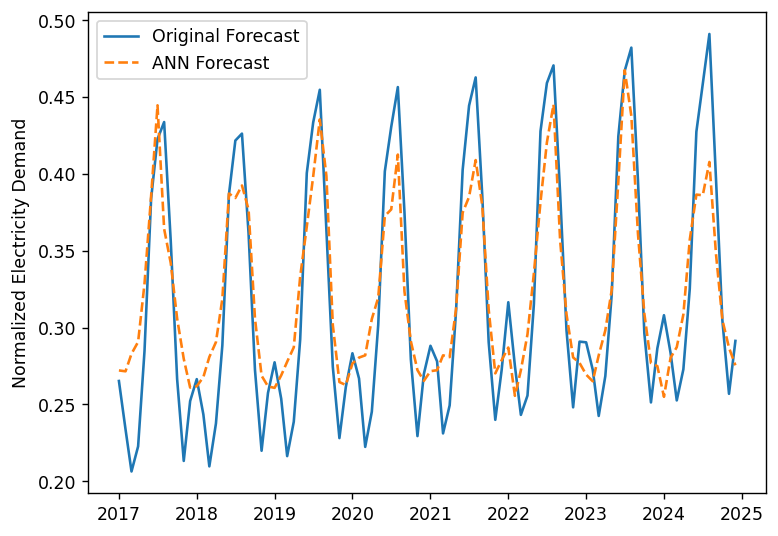

In [52]:
plt.plot(sampled_pred, label='Original Forecast')
plt.plot(sampled_ann, label='ANN Forecast', ls='--')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

## Use PCA to compare logits